In [4]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# K-Means Clustering

In [5]:
df = pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [6]:
df.columns

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [8]:
print('Dataset Info:')
df.info()
print('\nSummary Statistics:')
print(df.describe())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB

Summary Statistics:
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%

In [9]:
df['Genre'].value_counts()

Genre
Female    112
Male       88
Name: count, dtype: int64

In [10]:
print('Missing Values:')
print(df.isnull().sum())

Missing Values:
CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [11]:
df['Spending Score (1-100)'].value_counts()

Spending Score (1-100)
42    8
55    7
73    6
46    6
48    5
     ..
68    1
85    1
23    1
8     1
18    1
Name: count, Length: 84, dtype: int64

In [12]:
df.columns

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [13]:
fig = px.bar(df, x = 'Genre', title = 'Gender Distribution')
fig.show()

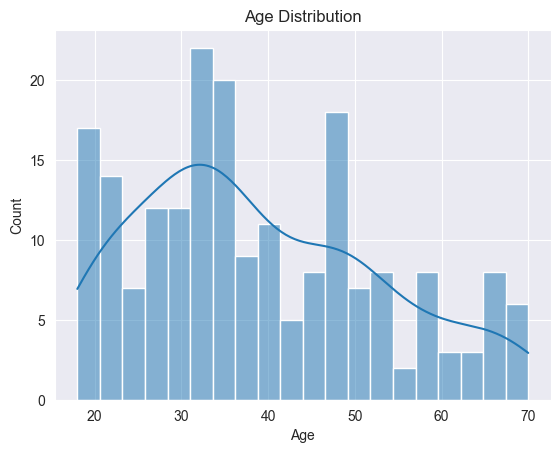

In [14]:
sns.histplot(df['Age'], bins = 20, kde = True)
plt.title('Age Distribution')
plt.show()

In [15]:
fig = px.scatter(df, x = 'Annual Income (k$)', y = 'Spending Score (1-100)', title = 'Income vs Spending Score')
fig.show()

In [16]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Annual Income (k$)'] = df['Annual Income (k$)'].fillna(df['Annual Income (k$)'].median())
df['Spending Score (1-100)'] = df['Spending Score (1-100)'].fillna(
    df['Spending Score (1-100)'].median()
)

print("Missing Values:")
print(df.isnull().sum())


Missing Values:
CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [17]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values
X

array([[ 15,  39],
       [ 15,  81],
       [ 16,   6],
       [ 16,  77],
       [ 17,  40],
       [ 17,  76],
       [ 18,   6],
       [ 18,  94],
       [ 19,   3],
       [ 19,  72],
       [ 19,  14],
       [ 19,  99],
       [ 20,  15],
       [ 20,  77],
       [ 20,  13],
       [ 20,  79],
       [ 21,  35],
       [ 21,  66],
       [ 23,  29],
       [ 23,  98],
       [ 24,  35],
       [ 24,  73],
       [ 25,   5],
       [ 25,  73],
       [ 28,  14],
       [ 28,  82],
       [ 28,  32],
       [ 28,  61],
       [ 29,  31],
       [ 29,  87],
       [ 30,   4],
       [ 30,  73],
       [ 33,   4],
       [ 33,  92],
       [ 33,  14],
       [ 33,  81],
       [ 34,  17],
       [ 34,  73],
       [ 37,  26],
       [ 37,  75],
       [ 38,  35],
       [ 38,  92],
       [ 39,  36],
       [ 39,  61],
       [ 39,  28],
       [ 39,  65],
       [ 40,  55],
       [ 40,  47],
       [ 40,  42],
       [ 40,  42],
       [ 42,  52],
       [ 42,  60],
       [ 43,

choosing k: the elbow method

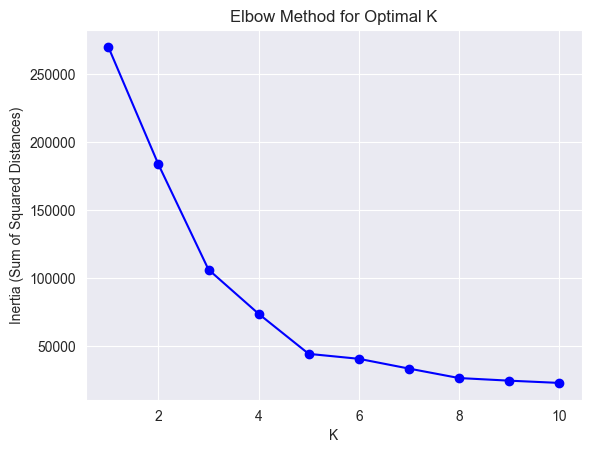

In [18]:
inertia = []
K = range(1, 11)
for k in K:
    km = KMeans(n_clusters = k, random_state = 42)
    km.fit(X)
    inertia.append(km.inertia_)
plt.plot(K, inertia, 'bo-')
plt.xlabel('K')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.title('Elbow Method for Optimal K')
plt.show()

# PCA (Principal Component Analysis)

In [19]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']])

pca = PCA(n_components = 2)
X_pca = pca.fit_transform(X_scaled)

print('Explained Variance:')
print(pca.explained_variance_ratio_)

Explained Variance:
[0.44266167 0.33308378]


In [20]:
pd.DataFrame(pca.components_, columns = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)'], index=['PC1', 'PC2'])

,Age,Annual Income (k$),Spending Score (1-100)
PC1,0.706382,-0.048024,-0.706199
PC2,0.030141,0.998832,-0.037775


In [21]:
kmeans_pca = KMeans(n_clusters = 5, random_state = 42)
clusters_pca = kmeans_pca.fit_predict(X_pca)

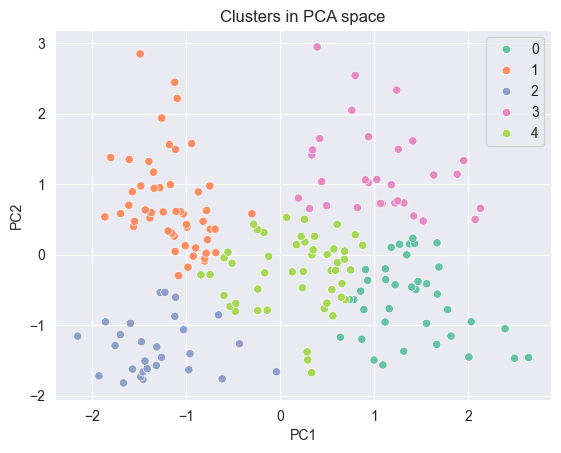

In [22]:
df['Cluster_PCA'] = clusters_pca

sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=clusters_pca, palette='Set2')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Clusters in PCA space')
plt.show()